In [24]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcdefaults()


In [25]:
# Configuration
DATA_FILE = 'all_spectra_found_dataset.csv'
OUTPUT_DIR = 'all_spectra_dereddened_analysis'
STYLE_FILE = '../GausSN.mplstyle'


<h2>
Filtering

In [26]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load Data
print(f"Loading data from {DATA_FILE}...")
if not os.path.exists(DATA_FILE):
    print(f"Error: {DATA_FILE} not found.")


df = pd.read_csv(DATA_FILE)

if df.empty:
    print("Error: Dataset is empty.")


print(f"Found {len(df)} spectra.")

# 2. Process and Filter
print("Applying filters (SNR >= 5, No 91T/91bg/Unknown)...")

# Subtype check: Exclude 91bg, 91T, and Unknown
def is_valid_subtype(st):
    st = str(st).lower()
    if any(x in st for x in ["91bg", "91t", "unknown", "n/a", "nan", "pec"]):
        return False
    return True

# Filter for SNR and Subtype
df_filtered = df[
    (df['SNR'] >= 10) &
    (df['Subtype'].apply(is_valid_subtype))
].copy()


Loading data from all_spectra_found_dataset.csv...
Found 2603 spectra.
Applying filters (SNR >= 5, No 91T/91bg/Unknown)...


<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_9378/3523413846.py:48: SyntaxWarning: invalid escape sequence '\s'
  metrics_text = f"$\sigma_t$: {sigma_t:.2f} days Bias: {bias:.2f} days"


Saved cleaned data with all columns to all_spectra_dereddened_analysis/full_range.csv
--- Statistics for Full Range Dataset (N=1470) ---
Sigma_t (Dispersion): 4.637 days
RMSE: 4.646 days
Mean Bias: 0.308 days
Correlation plot saved to all_spectra_dereddened_analysis/snid_vs_true_correlation_full_range.png


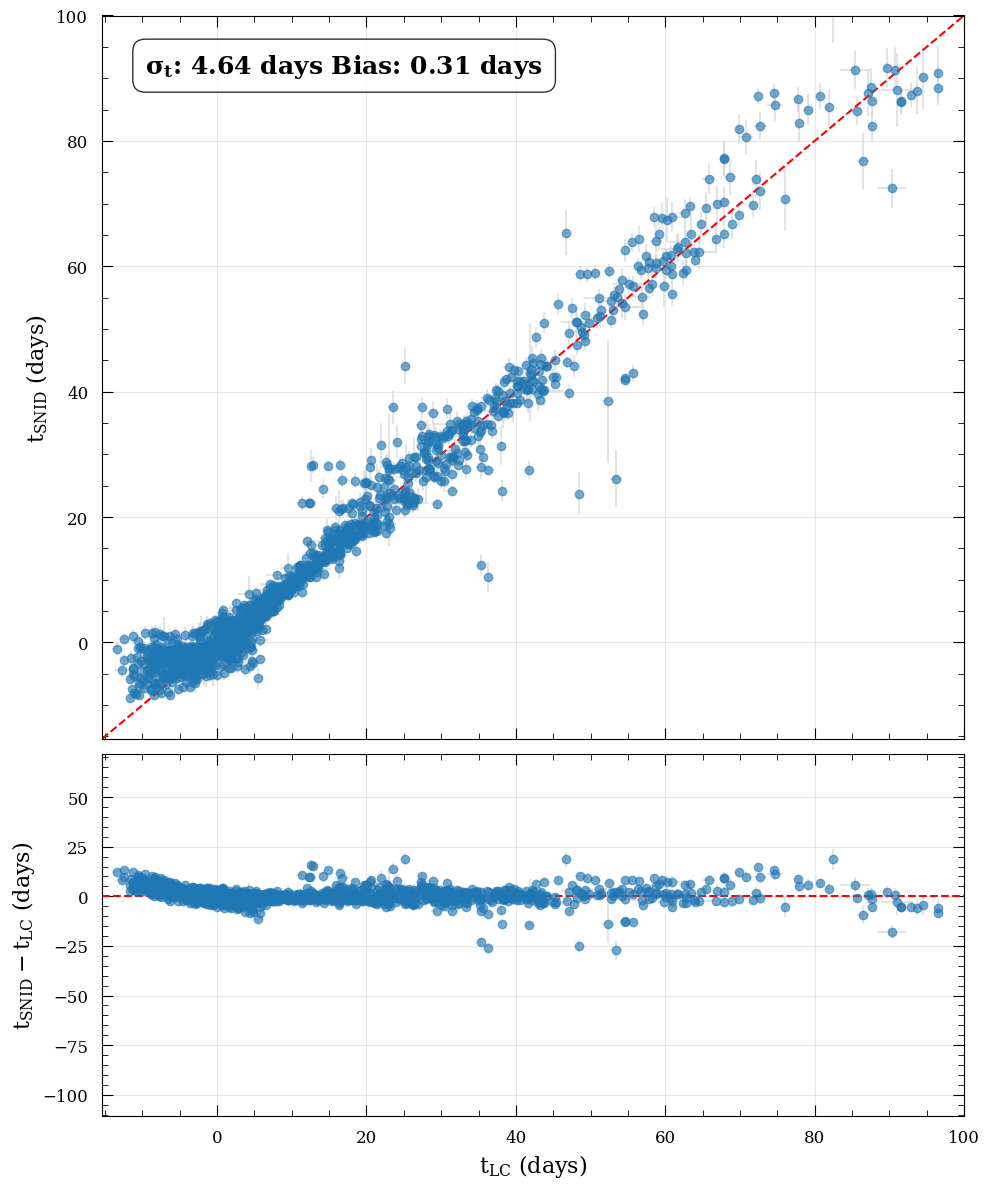

In [34]:
# Create plotting dataframe
df_plot = pd.DataFrame({
    'true_age': df_filtered['Age_(days)'],
    'true_unc': df_filtered['Age_Unc_(days)'].fillna(0.0),
    'estimated_age': df_filtered['bootstrap_age'],
    'std_err': df_filtered['snid_std_dev'],
    'residual': df_filtered['delta_age']
})

full_range_path = os.path.join(OUTPUT_DIR, 'full_range.csv')
df_plot.to_csv(full_range_path, index=False)
print(f"Saved cleaned data with all columns to {full_range_path}")

# 3. Plotting
if os.path.exists(STYLE_FILE):
    plt.style.use(STYLE_FILE)
else:
    print(f"Warning: {STYLE_FILE} not found, using default style.")

# Calculate metrics
# Note: Using 'residual' which was added in the previous step
sigma_t = df_plot['residual'].std()
rmse = np.sqrt((df_plot['residual']**2).mean())
bias = df_plot['residual'].mean()

print(f"--- Statistics for Full Range Dataset (N={len(df_plot)}) ---")
print(f"Sigma_t (Dispersion): {sigma_t:.3f} days")
print(f"RMSE: {rmse:.3f} days")
print(f"Mean Bias: {bias:.3f} days")

df_plot['total_error'] = np.sqrt(df_plot['std_err']**2 + df_plot['true_unc']**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Determine limits
all_ages = pd.concat([df_plot['true_age'], df_plot['estimated_age']])
min_age, max_age = all_ages.min() - 2, 100

# Top Panel: SNID Predicted Age vs True Age
ax1.errorbar(
    df_plot['true_age'], df_plot['estimated_age'],
    yerr=df_plot['std_err'], xerr=df_plot['true_unc'],
    fmt='o', alpha=0.6, ecolor='lightgray', capsize=0
)
ax1.plot([min_age, max_age], [min_age, max_age], color='red', linestyle='--')
ax1.set_ylabel(r"$t_{SNID}$ (days)")

metrics_text = f"$\sigma_t$: {sigma_t:.2f} days Bias: {bias:.2f} days"
ax1.text(0.05, 0.95, metrics_text, transform=ax1.transAxes,
         va='top', ha='left', fontsize=18, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8))

ax1.grid(True, alpha=0.3)
ax1.set_xlim(min_age, max_age)
ax1.set_ylim(min_age, max_age)

# Bottom Panel: Residuals
ax2.errorbar(
    df_plot['true_age'], df_plot['residual'],
    yerr=df_plot['total_error'], xerr=df_plot['true_unc'],
    fmt='o', alpha=0.6, ecolor='lightgray', capsize=0
)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel(r"$t_{LC}$ (days)")
ax2.set_ylabel(r"$t_{SNID} - t_{LC}$ (days)")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(min_age, max_age)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'snid_vs_true_correlation_full_range.png')
plt.savefig(plot_path, dpi=300)
print(f"Correlation plot saved to {plot_path}")
plt.show()
